In [1]:
import numpy as np
import matplotlib.pyplot as plt
import finufft
from scipy.fft import fft
from matplotlib.colors import LogNorm
import cmasher as cmr

In [12]:
# Calculate S3 over twice of n_modes to avoid undefined corners

In [2]:
def structure_3points_1D(sample, L, n_modes = 1000):

    sample = sample - L/2
    sample = (sample / L) * 2 * np.pi
    c = np.ones_like(sample, dtype = np.complex128)
    rho_k = finufft.nufft1d1(sample, c, 2*n_modes + 1)
    rho_k_1 = rho_k.copy()
    rho_k_1[n_modes] = 0

    # grid (k+k'), rho(k+k')*
    
    k_kp_ind = np.arange(- n_modes, n_modes + 1)
    k_kp_ind = k_kp_ind[:, None] + k_kp_ind[None, :]

    msk_k_kp_ind = np.where((k_kp_ind >= - n_modes) & (k_kp_ind <= n_modes), k_kp_ind, 0)
    msk_k_kp_ind = msk_k_kp_ind + n_modes
    msk_k_kp_ind = msk_k_kp_ind.astype(int)
    rho_kkp = np.conj(rho_k_1[msk_k_kp_ind])

    rho_k_rev = rho_k_1[:, None]
    rhok_rhokp = rho_k_rev * rho_k_1[None, :]

    S3_2K = rhok_rhokp * rho_kkp/len(sample)
    
    S3 = S3_2K[(n_modes//2):(n_modes+n_modes//2), (n_modes//2):(n_modes+n_modes//2)]

    # g3

    rho_kkp = np.conj(rho_k[msk_k_kp_ind])
    rho_k_rev = rho_k[:, None]
    rhok_rhokp = rho_k_rev * rho_k[None, :]

    S3_2K = rhok_rhokp * rho_kkp/len(sample)
    
    S3_1 = S3_2K[(n_modes//2):(n_modes+n_modes//2), (n_modes//2):(n_modes+n_modes//2)]

    g3 = np.fft.ifft2(np.fft.ifftshift(S3_1-1));
    n0 = len(sample)/L;
    g3 = (n_modes/n0) * np.real(np.fft.fftshift(g3)) + 1;

    return S3, g3

In [3]:
def radial_profile(data, center=None):
    
    ndim = len(data.shape)
    R = int(data.shape[0]/2)
    if center is None:
        center = np.array(data.shape)/2
    for i in range(ndim):
        center = np.expand_dims(center, axis=-1)
    idx = np.indices((data.shape))
    r = np.sqrt(np.sum((idx - center)**2,axis=0))
    r = r.astype(int)
    r = np.where(r <= R, r, R+1)
    tbin = np.bincount(r.ravel(),data.ravel())
    nr = np.bincount(r.ravel())
    radialprofile = np.divide(tbin, nr,  out=np.zeros_like(tbin, dtype=float), where=(nr != 0))
    
    return np.unique(r).ravel()[:-1], radialprofile[:-1]

Hard rod

In [4]:
N1 = 300
L1 = 1
n_modes_1 = 2000
N_ens = 1

phi_vals = np.array([0.07, 0.5, 0.97])

More accurate for n_modes > N

$\phi = \frac{N \sigma}{L_{f}}$

In [5]:
sigma_vals = (L1*(phi_vals))/(N1*(1-phi_vals))
L1_up = L1 + N1 * sigma_vals
extensions = np.arange(1, 2*(N1 - 1) + 2, 2)[None, :] * (sigma_vals[:, None]/2)

In [6]:
hard_rod_ens = []

for i in range(N_ens):

    hard_rod_samples = L1 * np.random.rand(len(phi_vals), N1);
    hard_rod_samples = np.sort(hard_rod_samples);
    hard_rod_samples = hard_rod_samples + extensions;
    hard_rod_samples = hard_rod_samples - L1_up[:, None]/2
    hard_rod_samples = hard_rod_samples/L1_up[:, None];
    hard_rod_ens.append(hard_rod_samples)

hard_rod_ens = np.array(hard_rod_ens)

In [7]:
S3_1_avg_vals = []
g3_1_avg_vals = []

for j in range(len(phi_vals)):

    hard_rod_ens_j = hard_rod_ens[:, j, :]

    S3_1_ens = []
    g3_1_ens = []

    for k in range(N_ens):

        S3_1, g3_1 = structure_3points_1D(hard_rod_ens_j[k, :], 1, n_modes_1);
        S3_1_ens.append(S3_1)
        g3_1_ens.append(g3_1)

    S3_1_avg = np.mean(S3_1_ens, 0)
    g3_1_avg = np.mean(g3_1_ens, 0)

    S3_1_avg_vals.append(S3_1_avg)
    g3_1_avg_vals.append(g3_1_avg)

S3_1_avg_vals = np.real(S3_1_avg_vals)  # ! Keep np.real instead of np.abs
g3_1_avg_vals = np.real(g3_1_avg_vals)

Plots

In [8]:
grid_1 = np.arange(- (n_modes_1//2), (n_modes_1 - 1)//2 + 1);
grid1 = np.linspace(-L1/2, L1/2, n_modes_1)

In [9]:
phi = phi_vals[2]

In [13]:
vmin_1a, vmax_1a = np.nanpercentile(S3_1_avg_vals[2], [0.5, 99.5])

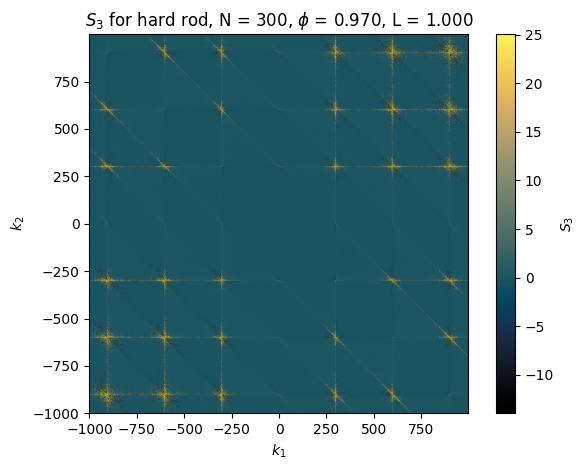

In [16]:
plt.figure()
plt.imshow(S3_1_avg_vals[2], origin = 'lower', cmap = cmr.eclipse, 
           extent=[grid_1[0], grid_1[-1], grid_1[0], grid_1[-1]], vmin=vmin_1a, vmax=vmax_1a)

plt.xlabel("$k_1$");
plt.ylabel("$k_2$");

plt.title(rf"$S_3$ for hard rod, N = {N1}, "rf"$\phi$ = {phi:.3f}, "rf"L = {L1:.3f}" )
plt.colorbar(label = "$S_3$")
plt.tight_layout();

In [20]:
vmin_1b, vmax_1b = np.nanpercentile(g3_1_avg_vals[2], [0.5, 99.5])

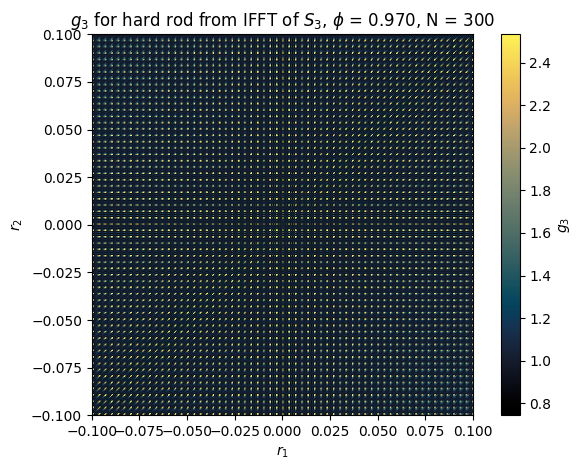

In [21]:
plt.figure()
plt.imshow(g3_1_avg_vals[2], origin = 'lower', 
           cmap = cmr.eclipse, extent=[grid1[0], grid1[-1], grid1[0], grid1[-1]], vmin=vmin_1b, vmax=vmax_1b)

plt.xlabel("$r_1$")
plt.ylabel("$r_2$")
plt.title(rf"$g_3$ for hard rod from IFFT of $S_3$, $\phi$ = {phi:.3f}, N = {N1}")
plt.colorbar(label = "$g_3$")
plt.xlim(-0.1, 0.1)
plt.ylim(-0.1, 0.1)
plt.tight_layout();

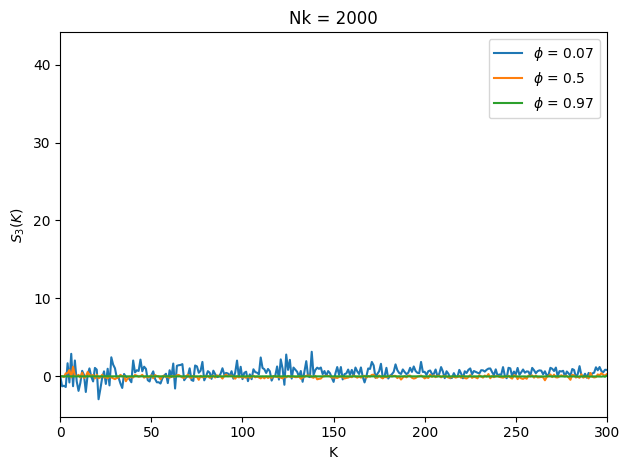

In [22]:
plt.figure()

for i in range(0, len(phi_vals)):

    phi_val = phi_vals[i]
    plt.plot(radial_profile(S3_1_avg_vals[i])[1], label = rf"$\phi$ = {phi_val}")

plt.xlabel("K")
plt.ylabel("$S_{3}(K)$")
plt.title(rf"Nk = {n_modes_1}")
plt.xlim(0, 300)
plt.legend()
plt.tight_layout(); 

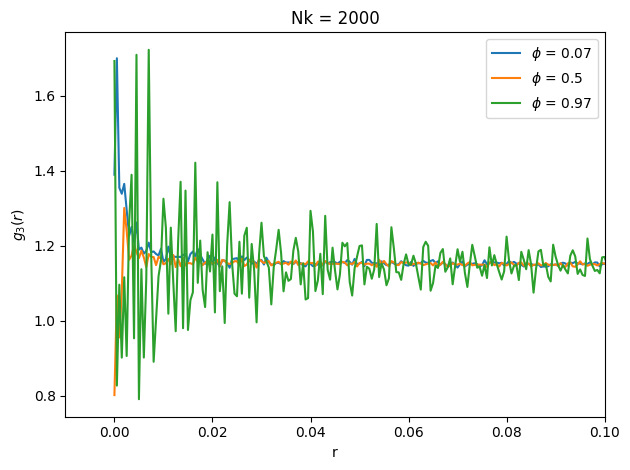

In [23]:
plt.figure()

for i in range(0, len(phi_vals)):

    phi_val = phi_vals[i]
    plt.plot(np.linspace(0, L1/2, n_modes_1//2 + 1), radial_profile(g3_1_avg_vals[i])[1], label = rf"$\phi$ = {phi_val}")

plt.xlabel("r")
plt.ylabel("$g_{3}(r)$")
plt.title(rf"Nk = {n_modes_1}")
plt.xlim(-0.01, 0.1)
#plt.ylim(0, 1.4)
plt.legend()
plt.tight_layout();

diagnostics

In [32]:
np.mean(S3_1_avg_vals[2].ravel())

0.6762194724480552

In [33]:
np.nanmax(S3_1_avg_vals[2])

14553.361266277983

In [34]:
np.nanmin(S3_1_avg_vals[2])

-2354.8251505996213

In [35]:
np.sum(np.where(S3_1_avg_vals[2] > 6, 1, 0))

63488

In [36]:
np.mean(g3_1_avg_vals[2].ravel())

1.1499983332135773

In [37]:
np.nanmax(g3_1_avg_vals[2])

7.175004584826808

In [38]:
np.nanmin(g3_1_avg_vals[2])

-0.34128886146374127